# Exploración de Datos (EDA) 



##  Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import math
import warnings
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

##  Carga del Dataset

In [2]:
CSV_PATH = 'datos/accepted_2007_to_2018Q4.csv'

df_raw = pd.read_csv(CSV_PATH, low_memory=False)

print(f'Filas   : {df_raw.shape[0]:,}')
print(f'Columnas: {df_raw.shape[1]:,}')
df_raw.head(3)

Filas   : 2,260,701
Columnas: 151


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## Variable Objetivo: `default`



In [3]:
df = df_raw[df_raw['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
df = df.drop(columns='loan_status')

counts = df['default'].value_counts()
pcts   = df['default'].value_counts(normalize=True) * 100

print(f'  Registros tras filtrado: {len(df):,}')
print(f'  Fully Paid  (0): {counts[0]:,}  ({pcts[0]:.1f}%)')
print(f'  Charged Off (1): {counts[1]:,}  ({pcts[1]:.1f}%)')

  Registros tras filtrado: 1,345,310
  Fully Paid  (0): 1,076,751  (80.0%)
  Charged Off (1): 268,559  (20.0%)


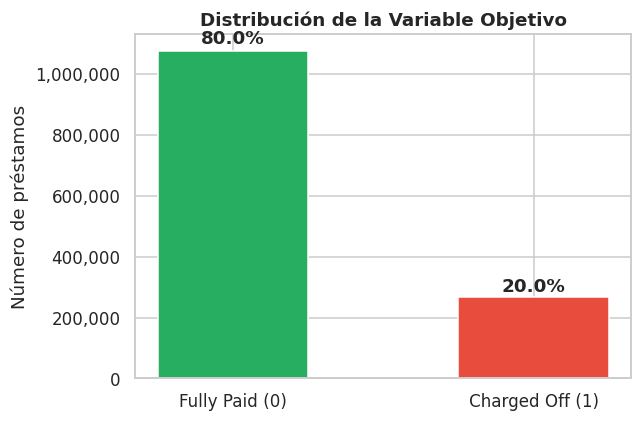

In [4]:
fig, ax = plt.subplots(figsize=(6,4))

# Barras
bars = ax.bar(['Fully Paid (0)', 'Charged Off (1)'], counts.values,
              color=['#27ae60', '#e74c3c'], edgecolor='white', width=0.5)

for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_title('Distribución de la Variable Objetivo', fontweight='bold')
ax.set_ylabel('Número de préstamos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('eda_01_target.png', bbox_inches='tight')
plt.show()

La variable `default` presenta un **desequilibrio significativo**:
- **Clase mayoritaria (0 — Fully Paid):** ~80% de los registros.  
- **Clase minoritaria (1 — Charged Off):** ~20% de los registros.  

Este desbalance debe tenerse en cuenta al entrenar el modelo.

##  Tipos de Datos y Valores Faltantes

###  Tipos de datos

In [5]:
type_summary = df.dtypes.value_counts().rename_axis('Tipo').reset_index(name='Cantidad')
print("Distribución de tipos de datos:")
print(type_summary.to_string(index=False))

Distribución de tipos de datos:
   Tipo  Cantidad
float64       113
 object        37
  int64         1


###  Diagnóstico de valores faltantes

In [6]:
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(f'Columnas con valores faltantes: {len(missing_pct)} de {df.shape[1]}')
missing_pct.head(20)

Columnas con valores faltantes: 105 de 151


member_id                                     100.000000
next_pymnt_d                                  100.000000
orig_projected_additional_accrued_interest     99.720585
hardship_length                                99.572292
hardship_dpd                                   99.572292
hardship_last_payment_amount                   99.572292
hardship_payoff_balance_amount                 99.572292
deferral_term                                  99.572292
payment_plan_start_date                        99.572292
hardship_amount                                99.572292
hardship_end_date                              99.572292
hardship_loan_status                           99.572292
hardship_type                                  99.572292
hardship_start_date                            99.572292
hardship_reason                                99.572292
hardship_status                                99.572292
sec_app_mths_since_last_major_derog            99.506062
sec_app_revol_util             

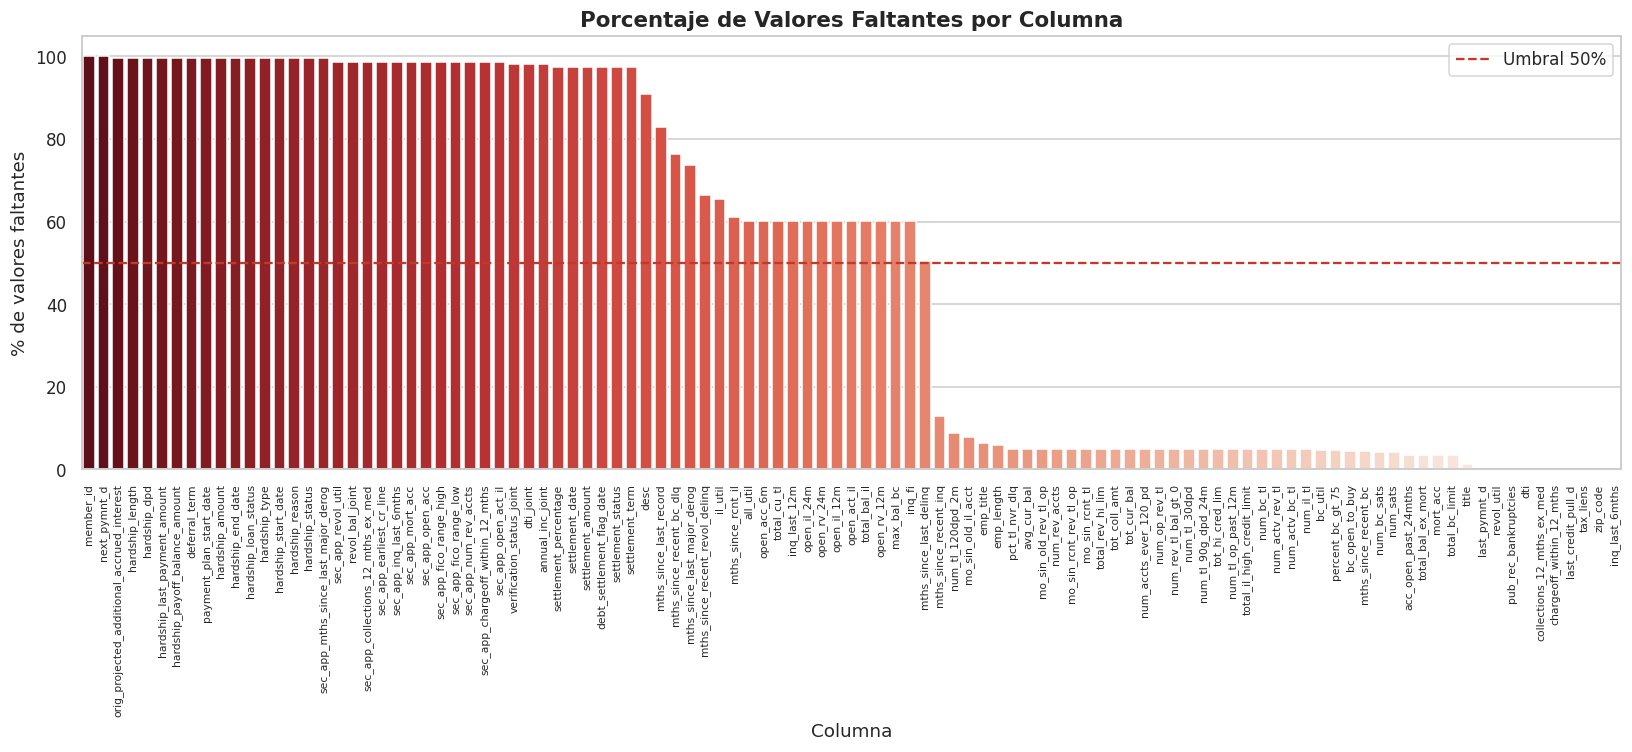

In [7]:
plt.figure(figsize=(15, 7))
sns.barplot(x=missing_pct.index, y=missing_pct.values,
            hue=missing_pct.index, palette='Reds_r', legend=False)
plt.axhline(50, color='#c0392b', linestyle='--', linewidth=1.5, label='Umbral 50%')
plt.title('Porcentaje de Valores Faltantes por Columna', fontsize=14, fontweight='bold')
plt.xlabel('Columna')
plt.ylabel('% de valores faltantes')
plt.xticks(rotation=90, fontsize=7)
plt.legend()
plt.tight_layout()
plt.savefig('eda_02_missing_before.png', bbox_inches='tight')
plt.show()

###  Eliminar columnas con más del 50% de nulos


In [8]:
threshold = 0.50
missing_ratio = df.isnull().sum() / len(df)
cols_to_drop = missing_ratio[missing_ratio > threshold].index

df = df.drop(columns=cols_to_drop)

print(f'Columnas eliminadas (>{int(threshold*100)}% nulos): {len(cols_to_drop)}')
print(f'Columnas restantes: {df.shape[1]}')

Columnas eliminadas (>50% nulos): 58
Columnas restantes: 93


Columnas con nulos restantes: 47


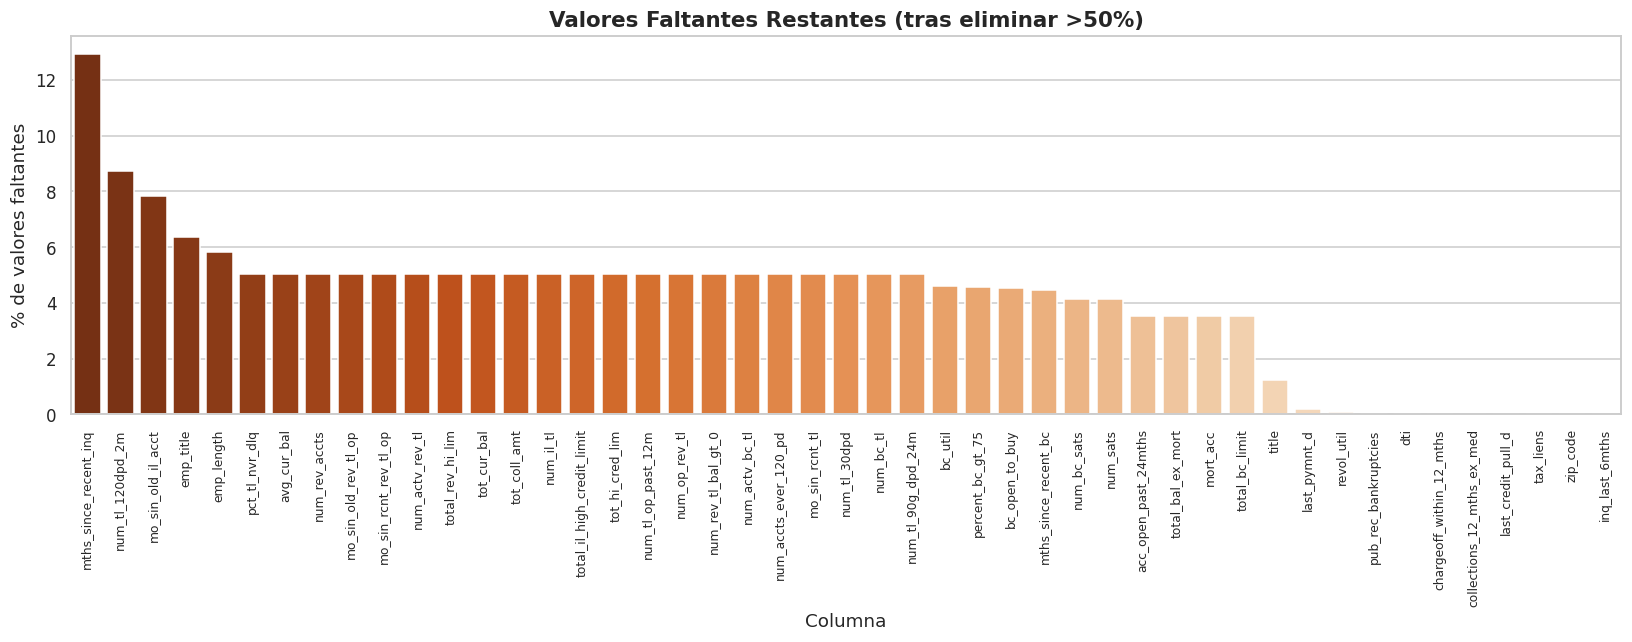

In [9]:
missing_pct2 = (df.isnull().sum() / len(df) * 100)
missing_pct2 = missing_pct2[missing_pct2 > 0].sort_values(ascending=False)

print(f'Columnas con nulos restantes: {len(missing_pct2)}')

plt.figure(figsize=(15, 6))
sns.barplot(x=missing_pct2.index, y=missing_pct2.values,
            hue=missing_pct2.index, palette='Oranges_r', legend=False)
plt.title('Valores Faltantes Restantes (tras eliminar >50%)', fontsize=14, fontweight='bold')
plt.xlabel('Columna')
plt.ylabel('% de valores faltantes')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig('eda_03_missing_after.png', bbox_inches='tight')
plt.show()

### Imputación de variables categóricas

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns
missing_cat = df[cat_cols].isnull().sum()
missing_cat = missing_cat[missing_cat > 0]

print('Datos faltantes en variables categóricas:')
print(missing_cat.to_string())

Datos faltantes en variables categóricas:
emp_title             85785
emp_length            78511
title                 16660
zip_code                  1
last_pymnt_d           2313
last_credit_pull_d       55


In [11]:
df_imp = df.copy()


cols_unknown = [c for c in ['emp_title', 'title', 'zip_code',
                             'last_pymnt_d', 'last_credit_pull_d'] if c in df_imp.columns]
for col in cols_unknown:
    df_imp[col] = df_imp[col].fillna('Unknown')

print(f' Imputadas con "Unknown": {cols_unknown}')

 Imputadas con "Unknown": ['emp_title', 'title', 'zip_code', 'last_pymnt_d', 'last_credit_pull_d']


In [12]:

if 'emp_length' in df_imp.columns:
    df_imp['emp_length'] = (df_imp['emp_length']
                            .replace('10+ years', '10')
                            .replace('< 1 year', '0')
                            .str.replace(' years', '', regex=False)
                            .str.replace(' year', '', regex=False))
    df_imp['emp_length'] = pd.to_numeric(df_imp['emp_length'], errors='coerce')
    mediana_emp = df_imp['emp_length'].median()
    df_imp['emp_length'] = df_imp['emp_length'].fillna(mediana_emp)
    print(f'emp_length convertida a numérico — mediana imputada: {mediana_emp}')
    print(df_imp['emp_length'].value_counts().sort_index().to_string())

emp_length convertida a numérico — mediana imputada: 6.0
emp_length
0.0     108061
1.0      88494
2.0     121743
3.0     107597
4.0      80556
5.0      84154
6.0     141244
7.0      59624
8.0      60701
9.0      50937
10.0    442199


###  Imputación de variables numéricas

In [13]:
num_cols = df_imp.select_dtypes(include=['number']).columns
missing_num = df_imp[num_cols].isnull().sum()
missing_num = missing_num[missing_num > 0]

print('Datos faltantes en variables numéricas:')
print(missing_num.to_string())

Datos faltantes en variables numéricas:
dti                              374
inq_last_6mths                     1
revol_util                       857
collections_12_mths_ex_med        56
tot_coll_amt                   67527
tot_cur_bal                    67527
total_rev_hi_lim               67527
acc_open_past_24mths           47281
avg_cur_bal                    67549
bc_open_to_buy                 61143
bc_util                        61912
chargeoff_within_12_mths          56
mo_sin_old_il_acct            105575
mo_sin_old_rev_tl_op           67528
mo_sin_rcnt_rev_tl_op          67528
mo_sin_rcnt_tl                 67527
mort_acc                       47281
mths_since_recent_bc           60221
mths_since_recent_inq         174071
num_accts_ever_120_pd          67527
num_actv_bc_tl                 67527
num_actv_rev_tl                67527
num_bc_sats                    55841
num_bc_tl                      67527
num_il_tl                      67527
num_op_rev_tl                  6752

In [14]:
imputer = SimpleImputer(strategy='median')
df_imp[num_cols] = imputer.fit_transform(df_imp[num_cols])

total_nulos = df_imp.isnull().sum().sum()
print(f' Imputación con mediana completada')
print(f'   Nulos restantes en el dataset: {total_nulos}')

 Imputación con mediana completada
   Nulos restantes en el dataset: 0


## Selección de Variables 


In [15]:
NUM_COLS = [c for c in ['loan_amnt', 'int_rate', 'fico_range_low', 'fico_range_high',
                         'annual_inc', 'dti', 'installment', 'open_acc',
                         'pub_rec', 'revol_util', 'mort_acc', 'avg_cur_bal']
            if c in df_imp.columns]

print(f'Variables seleccionadas ({len(NUM_COLS)}): {NUM_COLS}')
df_imp[NUM_COLS + ['default']].describe().round(2)

Variables seleccionadas (12): ['loan_amnt', 'int_rate', 'fico_range_low', 'fico_range_high', 'annual_inc', 'dti', 'installment', 'open_acc', 'pub_rec', 'revol_util', 'mort_acc', 'avg_cur_bal']


,loan_amnt,int_rate,fico_range_low,fico_range_high,annual_inc,dti,installment,open_acc,pub_rec,revol_util,mort_acc,avg_cur_bal,default
count,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.00,1345310.0
mean,14419.97,13.24,696.19,700.19,76247.64,18.28,438.08,11.59,0.22,51.81,1.65,13183.25,0.2
std,8717.05,4.77,31.85,31.85,69925.10,11.16,261.51,5.47,0.60,24.51,1.97,15930.93,0.4
min,500.00,5.31,625.00,629.00,0.00,-1.00,4.93,0.00,0.00,0.00,0.00,0.00,0.0
25%,8000.00,9.75,670.00,674.00,45780.00,11.79,248.48,8.00,0.00,33.50,0.00,3238.00,0.0
50%,12000.00,12.74,690.00,694.00,65000.00,17.61,375.43,11.00,0.00,52.20,1.00,7407.00,0.0
75%,20000.00,15.99,710.00,714.00,90000.00,24.05,580.73,14.00,0.00,70.70,3.00,17931.00,0.0
max,40000.00,30.99,845.00,850.00,10999200.00,999.00,1719.83,90.00,86.00,892.30,51.00,958084.00,1.0


## Histogramas de Variables Numéricas



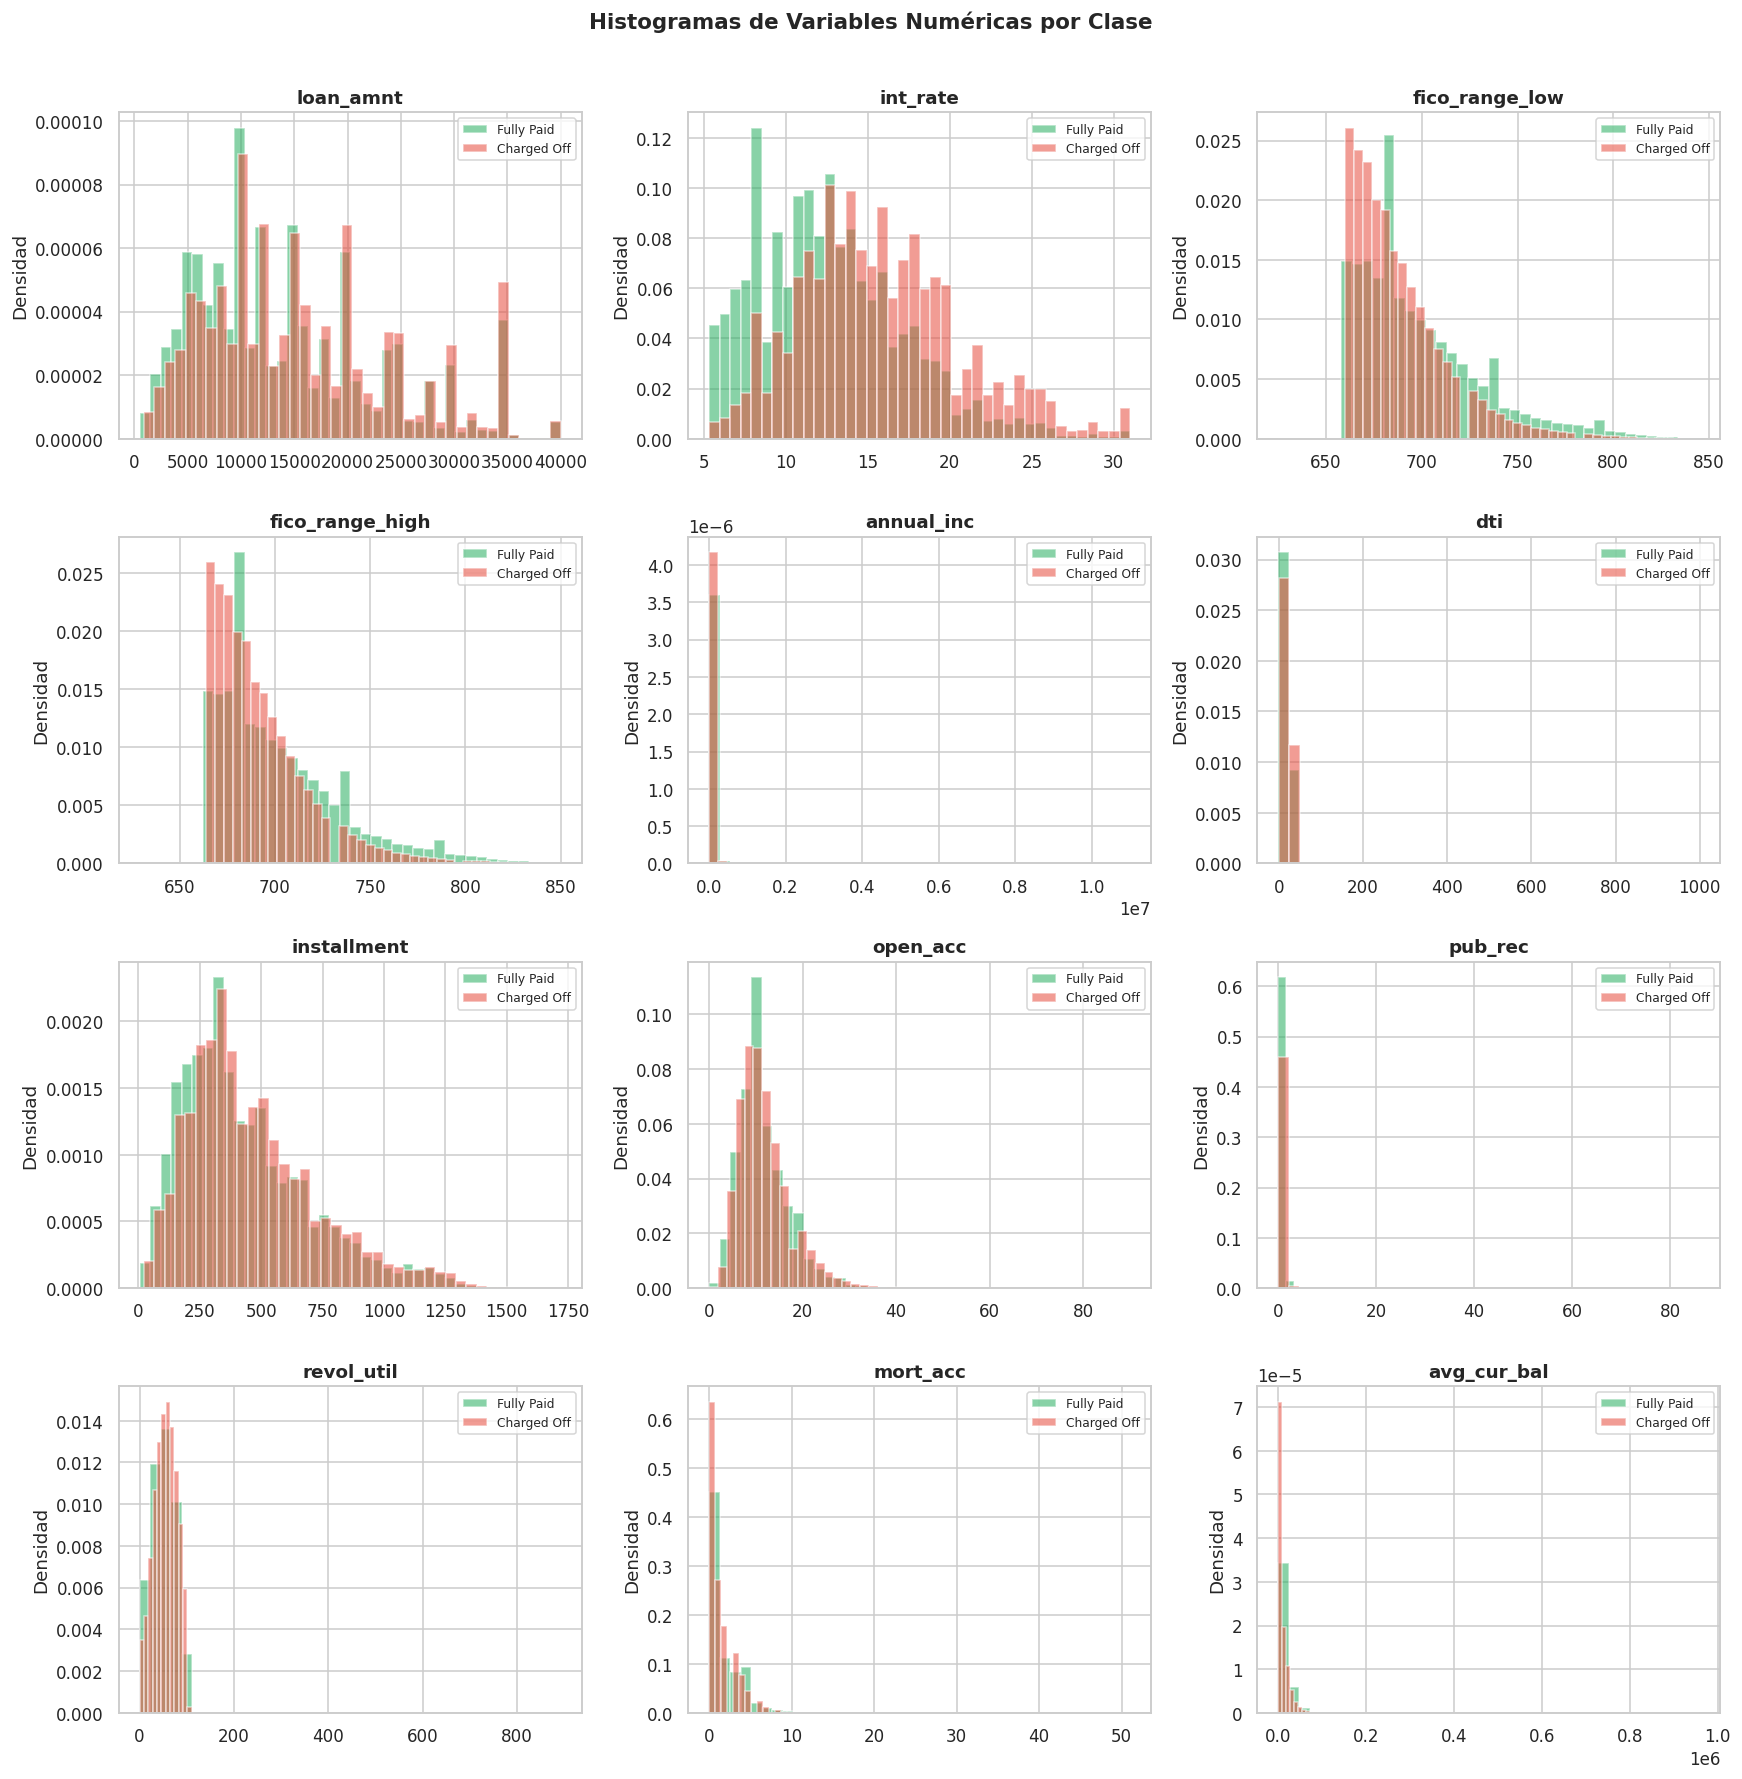

In [16]:
n_cols_g = 3
n_rows_g = math.ceil(len(NUM_COLS) / n_cols_g)

fig, axes = plt.subplots(n_rows_g, n_cols_g, figsize=(16, n_rows_g * 4))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    for label, color, name in [(0,'#27ae60','Fully Paid'), (1,'#e74c3c','Charged Off')]:
        subset = df_imp[df_imp['default'] == label][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.55, color=color, label=name, density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogramas de Variables Numéricas por Clase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_04_histograms.png', bbox_inches='tight')
plt.show()

##  Boxplots por Clase



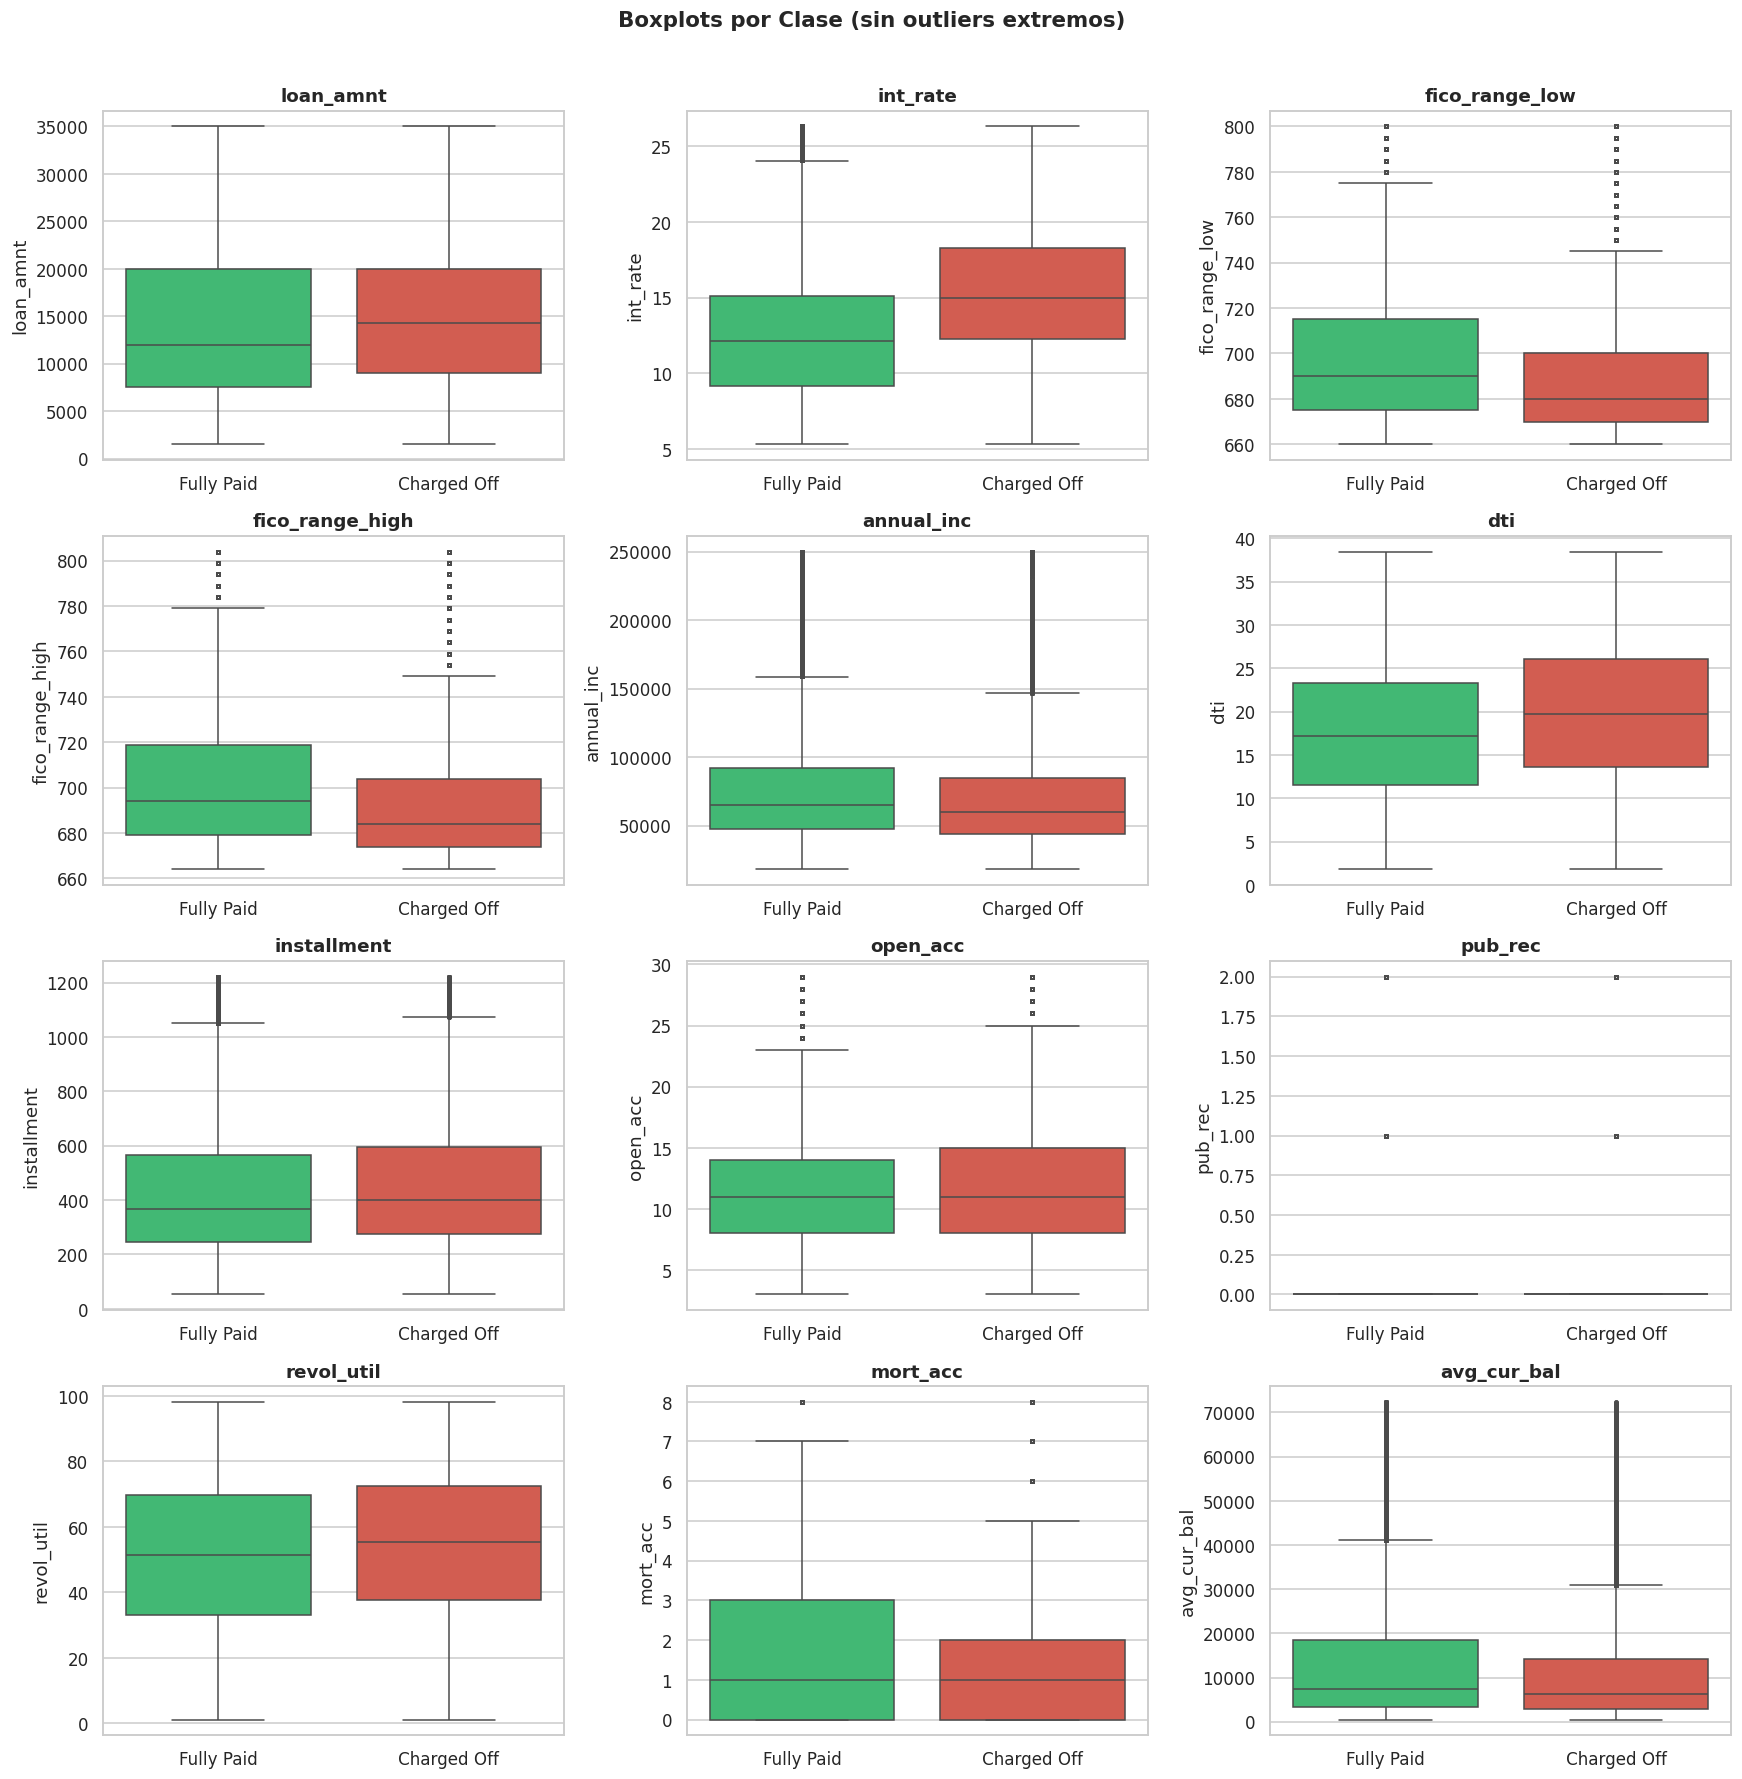

In [17]:
fig, axes = plt.subplots(n_rows_g, n_cols_g, figsize=(16, n_rows_g * 4))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    data_plot = df_imp[['default', col]].dropna()
    q_lo, q_hi = data_plot[col].quantile([0.01, 0.99])
    data_plot = data_plot[(data_plot[col] >= q_lo) & (data_plot[col] <= q_hi)]

    sns.boxplot(data=data_plot, x=data_plot['default'].astype(int), y=col,
            palette = {'0': '#2ecc71', '1': '#e74c3c'}, ax=axes[i],
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels(['Fully Paid', 'Charged Off'])
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots por Clase (sin outliers extremos)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_05_boxplots.png', bbox_inches='tight')
plt.show()

##  Correlaciones

###  Correlación con la variable objetivo

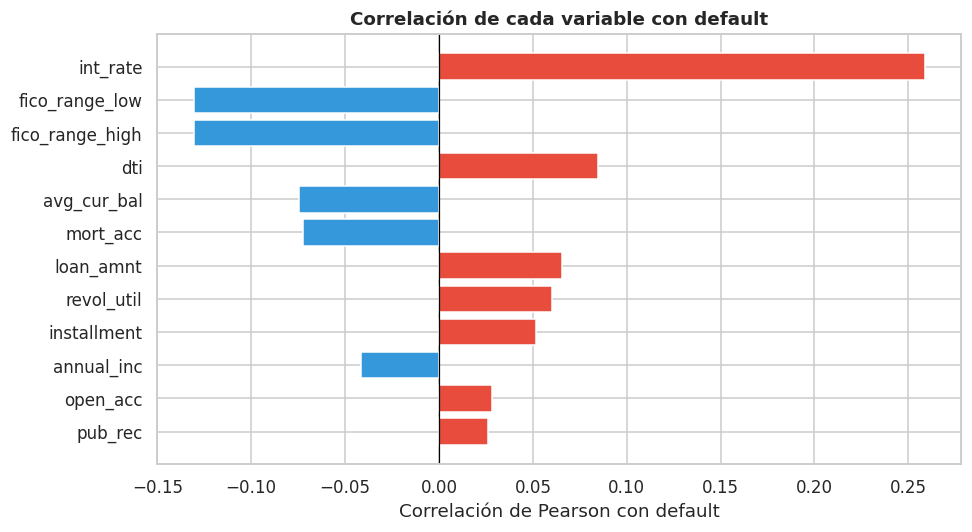

int_rate           0.258792
fico_range_low    -0.130683
fico_range_high   -0.130682
dti                0.084499
avg_cur_bal       -0.074760
mort_acc          -0.072468
loan_amnt          0.065604
revol_util         0.060029
installment        0.051701
annual_inc        -0.041759
open_acc           0.028078
pub_rec            0.026194


In [18]:
corr_target = (df_imp[NUM_COLS + ['default']]
               .corr()['default']
               .drop('default')
               .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con default')
ax.set_title('Correlación de cada variable con default', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('eda_06_corr_target.png', bbox_inches='tight')
plt.show()

print(corr_target.to_string())

###  Matriz de correlación completa

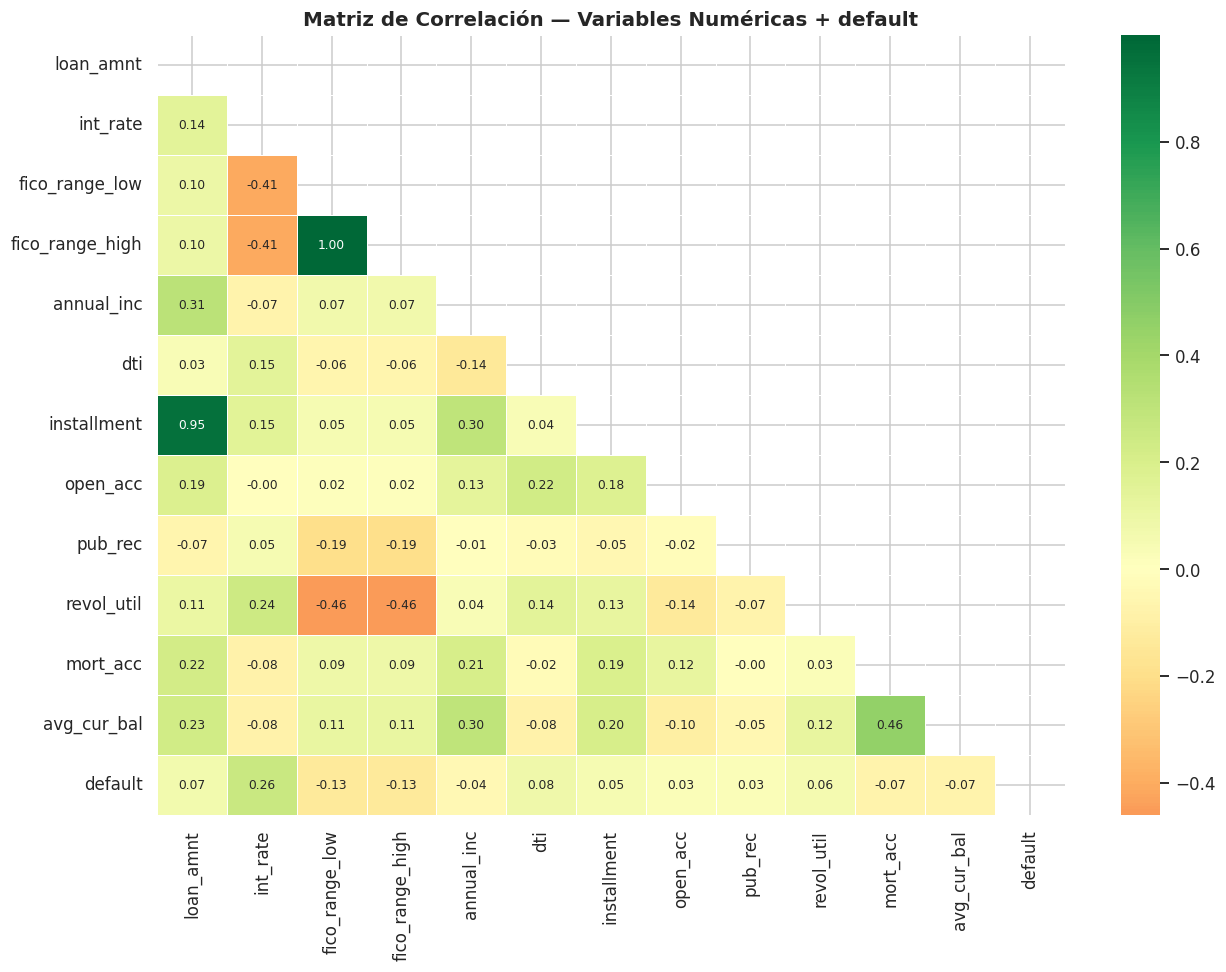

In [19]:
corr_matrix = df_imp[NUM_COLS + ['default']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de Correlación — Variables Numéricas + default',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_07_heatmap.png', bbox_inches='tight')
plt.show()

In [20]:
df_imp.to_csv('df_clean.csv', index=False)